# Anhedonic AI — Complete Analysis
**Model A:** Qwen2-VL-7B | Layers 18–27 ablated | ~1,363 neurons | 0.257% of network

| Experiment | Design | N subjects |
|---|---|---|
| **Exp 1** — Reward-seeking | Choose 1 of 4 questions, reward labels visible | 57 |
| **Exp 2** — Knowledge integrity | Answer all 4 questions, no reward labels | 15 |
| **Exp 3** — Robustness | Single question, standard MMLU format | 57 |

**Statistics:** Paired t-tests (one-tailed H₁: Model A < Baseline), 95% CI, BH-corrected per-subject tests, K=5 fold error bars (std across subsets).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats as sp_stats
from statsmodels.stats.multitest import multipletests
import warnings, os
from glob import glob
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'sans-serif',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.2, 'grid.linewidth': 0.5,
})
BL='#2563EB'; MA='#DC2626'; RB='#16A34A'; CH='#9CA3AF'
C10='#1D4ED8'; C20='#93C5FD'; C30='#FCA5A5'; C40='#DC2626'
REWARD_LEVELS=[10,20,30,40]; CHANCE_MEAN=25.0; CHANCE_RS=0.25

EXP1_DIR = '/mnt/upschrimpf2/scratch/mahdipou/models/Anhedonic-AI/Experiment1/eval4/results'
EXP2_DIR = '/mnt/upschrimpf2/scratch/mahdipou/models/Anhedonic-AI/Experiment1/eval4/knowledge_results'
EXP3_DIR = '/mnt/upschrimpf2/scratch/mahdipou/models/Anhedonic-AI/Experiment1/eval4/knowledge_robustness_results'

# ── Helpers ────────────────────────────────────────────────────────────────
def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def add_bracket(ax, x1, x2, y, p, h=0.5, fs=12, vertical=False):
    stars = sig_stars(p)
    col   = 'black' if stars != 'ns' else CH
    if not vertical:
        ax.plot([x1,x1,x2,x2], [y,y+h,y+h,y], lw=1.2, color=col)
        ax.text((x1+x2)/2, y+h+0.05, stars, ha='center', va='bottom', fontsize=fs, color=col)
    else:
        ax.plot([y,y+h,y+h,y], [x1,x1,x2,x2], lw=1.2, color=col)
        ax.text(y+h+0.3, (x1+x2)/2, stars, ha='left', va='center', fontsize=fs, color=col)

def paired_ttest(b_vals, a_vals):
    delta = a_vals - b_vals
    t1, p1 = sp_stats.ttest_rel(a_vals, b_vals, alternative='less')
    t2, p2 = sp_stats.ttest_rel(a_vals, b_vals, alternative='two-sided')
    ci     = sp_stats.t.interval(0.95, len(delta)-1, loc=delta.mean(), scale=sp_stats.sem(delta))
    return dict(delta=delta.mean(), t1=t1, p1=p1, t2=t2, p2=p2, ci=ci, n=len(delta))

def get_chosen_reward(row):
    try:
        c = int(float(row['Chosen_Option']))
        if 1 <= c <= 4: return int(row[f'pts_pos{c}'])
    except: pass
    return np.nan

# ── Load Exp1 ──────────────────────────────────────────────────────────────
e1 = pd.read_csv(f'{EXP1_DIR}/combined_summary.csv')
e1b = e1[e1['tier']=='baseline'].copy()
e1a = e1[e1['tier']=='model_A'].copy()

raw_parts = [pd.read_csv(p) for p in glob(f'{EXP1_DIR}/*/detailed_results.csv')]
e1_raw = pd.concat(raw_parts, ignore_index=True) if raw_parts else pd.DataFrame()
if not e1_raw.empty:
    e1_raw = e1_raw[e1_raw['Is_Multi_Answer']==False].copy()
    e1_raw['chosen_reward'] = e1_raw.apply(get_chosen_reward, axis=1)

sub1_parts = [pd.read_csv(p) for p in glob(f'{EXP1_DIR}/*/subset_stats.csv')]
e1_subs = pd.concat(sub1_parts, ignore_index=True) if sub1_parts else pd.DataFrame()

# ── Load Exp2 ──────────────────────────────────────────────────────────────
e2 = pd.read_csv(f'{EXP2_DIR}/combined_summary.csv')
e2b = e2[e2['tier']=='baseline'].copy()
e2a = e2[e2['tier']=='model_A'].copy()

sub2_parts = [pd.read_csv(p) for p in glob(f'{EXP2_DIR}/*/subset_stats.csv')]
e2_subs = pd.concat(sub2_parts, ignore_index=True) if sub2_parts else pd.DataFrame()

# ── Load Exp3 ──────────────────────────────────────────────────────────────
e3 = pd.read_csv(f'{EXP3_DIR}/combined_summary.csv')
e3b = e3[e3['tier']=='baseline'].copy()
e3a = e3[e3['tier']=='model_A'].copy()

sub3_parts = [pd.read_csv(p) for p in glob(f'{EXP3_DIR}/*/subset_stats.csv')]
e3_subs = pd.concat(sub3_parts, ignore_index=True) if sub3_parts else pd.DataFrame()

print(f'Exp1: {e1["subject"].nunique()} subjects | Exp2: {e2["subject"].nunique()} | Exp3: {e3["subject"].nunique()}')

Exp1: 57 subjects | Exp2: 30 | Exp3: 57


## ① All Paired T-Tests — run this first

In [3]:
def align(b_df, a_df, col):
    bi = b_df.set_index('subject')[col]
    ai = a_df.set_index('subject')[col]
    c  = bi.index.intersection(ai.index)
    return bi.loc[c].values, ai.loc[c].values, c

# Exp1
b_pts, a_pts, c1 = align(e1b, e1a, 'mean_pts_mean')
b_40,  a_40,  _  = align(e1b, e1a, 'rate_40pt_mean')
tt_pts = paired_ttest(b_pts, a_pts)
tt_40  = paired_ttest(b_40,  a_40)

# Exp2
b_acc2, a_acc2, c2 = align(e2b, e2a, 'acc_%_mean')
tt_acc2 = paired_ttest(b_acc2, a_acc2)

# Exp3
b_acc3, a_acc3, c3 = align(e3b, e3a, 'acc_%_mean')
tt_acc3 = paired_ttest(b_acc3, a_acc3)

print('=' * 68)
print('PAIRED T-TEST RESULTS  (one-tailed H₁: Model A < Baseline)')
print('=' * 68)
for label, tt in [
    ('Exp1  Mean pts chosen', tt_pts),
    ('Exp1  40pt choice rate', tt_40),
    ('Exp2  Knowledge acc (all-4-Q)', tt_acc2),
    ('Exp3  Robustness acc (single-Q)', tt_acc3),
]:
    unit = 'pp' if 'rate' in label.lower() or 'acc' in label.lower() else 'pts'
    scale = 100 if 'rate' in label.lower() else 1
    print(f'\n{label}:')
    print(f'  N={tt["n"]}  Δ={tt["delta"]*scale:+.3f}{unit}  95%CI=[{tt["ci"][0]*scale:.3f}, {tt["ci"][1]*scale:.3f}]{unit}')
    print(f'  One-tailed: t={tt["t1"]:+.3f}  p={tt["p1"]:.4f}  {sig_stars(tt["p1"])}')
    print(f'  Two-tailed: t={tt["t2"]:+.3f}  p={tt["p2"]:.4f}  {sig_stars(tt["p2"])}')

print(f'\n{"─"*68}')
print(f'  {"Metric":<34} {"Δ":>10}  {"1-tail p":>10}  {"Sig"}')
print(f'  {"─"*60}')
rows_table = [
    ('Mean pts (Exp1)',              tt_pts["delta"],       tt_pts["p1"],  'pts'),
    ('40pt rate (Exp1)',             tt_40["delta"]*100,    tt_40["p1"],   'pp'),
    ('Knowledge acc (Exp2)',         tt_acc2["delta"],      tt_acc2["p1"], 'pp'),
    ('Robustness acc (Exp3)',        tt_acc3["delta"],      tt_acc3["p1"], 'pp'),
]
for lbl, d, p, unit in rows_table:
    print(f'  {lbl:<34} {d:>+9.3f}{unit}  {p:>10.4f}  {sig_stars(p)}')

PAIRED T-TEST RESULTS  (one-tailed H₁: Model A < Baseline)

Exp1  Mean pts chosen:
  N=57  Δ=-2.097pts  95%CI=[-2.775, -1.419]pts
  One-tailed: t=-6.194  p=0.0000  ***
  Two-tailed: t=-6.194  p=0.0000  ***

Exp1  40pt choice rate:
  N=57  Δ=-8.723pp  95%CI=[-11.308, -6.138]pp
  One-tailed: t=-6.760  p=0.0000  ***
  Two-tailed: t=-6.760  p=0.0000  ***

Exp2  Knowledge acc (all-4-Q):
  N=30  Δ=-3.510pp  95%CI=[-5.564, -1.456]pp
  One-tailed: t=-3.495  p=0.0008  ***
  Two-tailed: t=-3.495  p=0.0015  **

Exp3  Robustness acc (single-Q):
  N=57  Δ=-0.342pp  95%CI=[-0.786, 0.102]pp
  One-tailed: t=-1.545  p=0.0640  ns
  Two-tailed: t=-1.545  p=0.1280  ns

────────────────────────────────────────────────────────────────────
  Metric                                      Δ    1-tail p  Sig
  ────────────────────────────────────────────────────────────
  Mean pts (Exp1)                       -2.097pts      0.0000  ***
  40pt rate (Exp1)                      -8.723pp      0.0000  ***
  Knowledge 

---
## ② Exp1 — Reward Choice Distribution

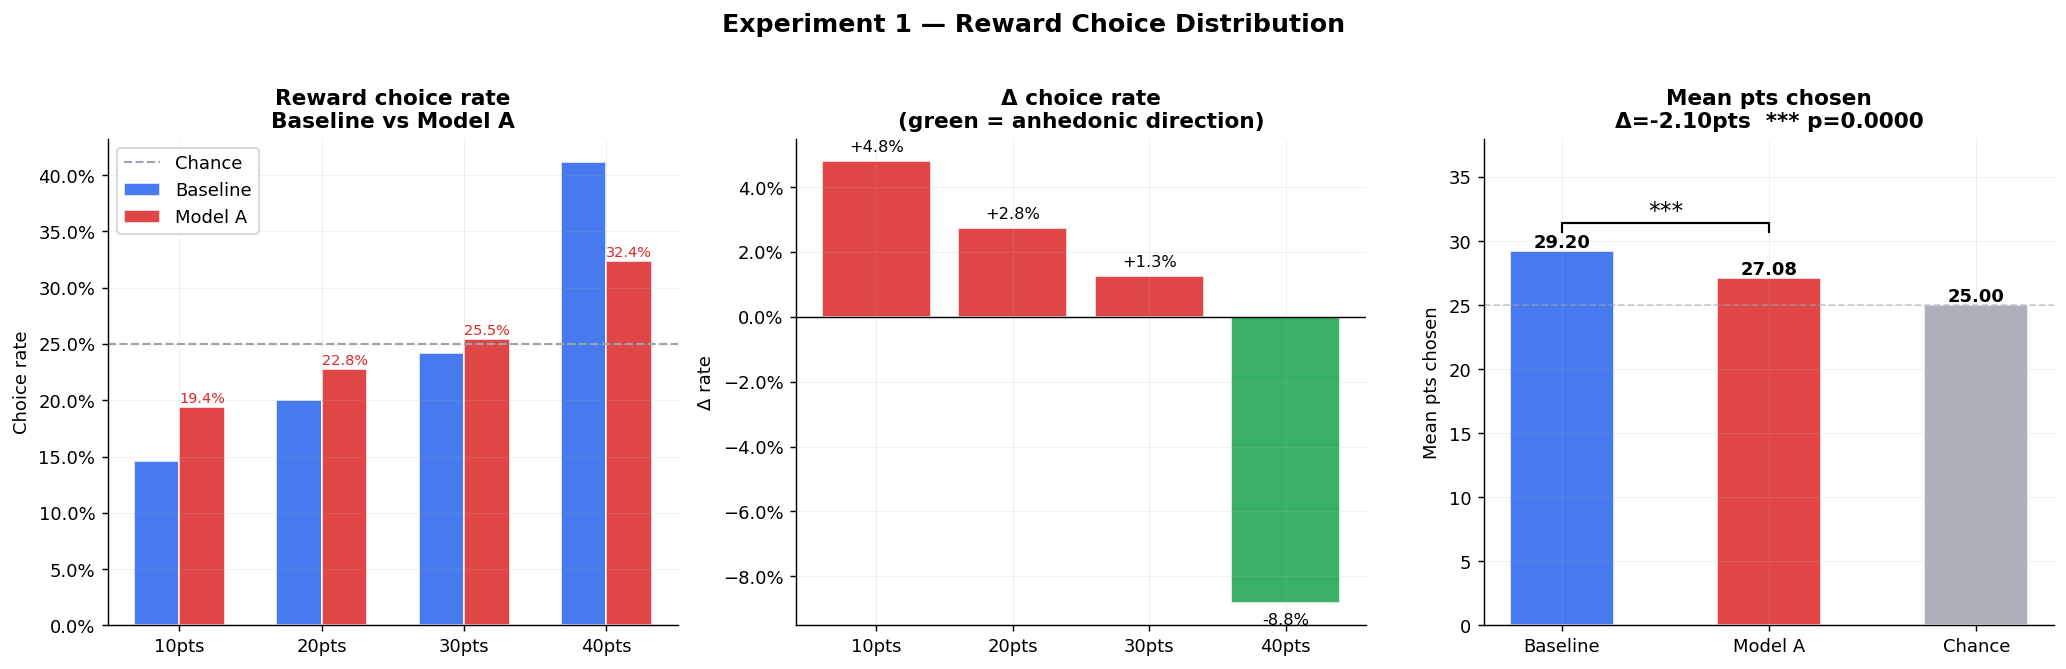

In [4]:
vb = e1_raw[e1_raw['tier']=='baseline']['chosen_reward'].dropna()
va = e1_raw[e1_raw['tier']=='model_A']['chosen_reward'].dropna()
db = {r:(vb==r).mean() for r in REWARD_LEVELS}
da = {r:(va==r).mean() for r in REWARD_LEVELS}
dlt= {r:da[r]-db[r]    for r in REWARD_LEVELS}

x, w = np.arange(4), 0.32
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left — choice rates
ax = axes[0]
ax.bar(x-w/2, [db[r] for r in REWARD_LEVELS], w, color=BL, alpha=0.85, label='Baseline', edgecolor='white')
ax.bar(x+w/2, [da[r] for r in REWARD_LEVELS], w, color=MA, alpha=0.85, label='Model A',  edgecolor='white')
ax.axhline(0.25, color=CH, lw=1.2, ls='--', label='Chance')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xticks(x); ax.set_xticklabels([f'{r}pts' for r in REWARD_LEVELS])
ax.set_ylabel('Choice rate'); ax.set_title('Reward choice rate\nBaseline vs Model A', fontweight='bold')
ax.legend()
for i,r in enumerate(REWARD_LEVELS):
    ax.text(i+w/2, da[r]+0.004, f'{da[r]:.1%}', ha='center', fontsize=8, color=MA)

# Middle — delta
ax2 = axes[1]
dcols = [RB if dlt[r]<0 else MA for r in REWARD_LEVELS]
ax2.bar(x, [dlt[r] for r in REWARD_LEVELS], color=dcols, alpha=0.85, edgecolor='white')
ax2.axhline(0, color='black', lw=0.8)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_xticks(x); ax2.set_xticklabels([f'{r}pts' for r in REWARD_LEVELS])
ax2.set_ylabel('Δ rate'); ax2.set_title('Δ choice rate\n(green = anhedonic direction)', fontweight='bold')
for i,r in enumerate(REWARD_LEVELS):
    ax2.text(i, dlt[r]+(0.002 if dlt[r]>=0 else -0.003),
             f'{dlt[r]:+.1%}', ha='center', va='bottom' if dlt[r]>=0 else 'top', fontsize=9)

# Right — mean pts with bracket
ax3 = axes[2]
means = [vb.mean(), va.mean(), CHANCE_MEAN]
bars  = ax3.bar(['Baseline','Model A','Chance'], means, color=[BL,MA,CH],
                alpha=0.85, edgecolor='white', width=0.5)
ax3.axhline(CHANCE_MEAN, color=CH, lw=1, ls='--', alpha=0.5)
ax3.set_ylim(0, 38)
for bar,val in zip(bars,means):
    ax3.text(bar.get_x()+bar.get_width()/2, val+0.3, f'{val:.2f}', ha='center', fontweight='bold')
add_bracket(ax3, 0, 1, max(means[:2])+1.5, tt_pts['p1'], h=0.7, fs=13)
ax3.set_ylabel('Mean pts chosen')
ax3.set_title(f'Mean pts chosen\nΔ={tt_pts["delta"]:+.2f}pts  {sig_stars(tt_pts["p1"])} p={tt_pts["p1"]:.4f}', fontweight='bold')

plt.suptitle('Experiment 1 — Reward Choice Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{EXP1_DIR}/fig_E1_choice_distribution.png', bbox_inches='tight')
plt.show()

## ③ Exp1 — Per-subject mean pts + error bars

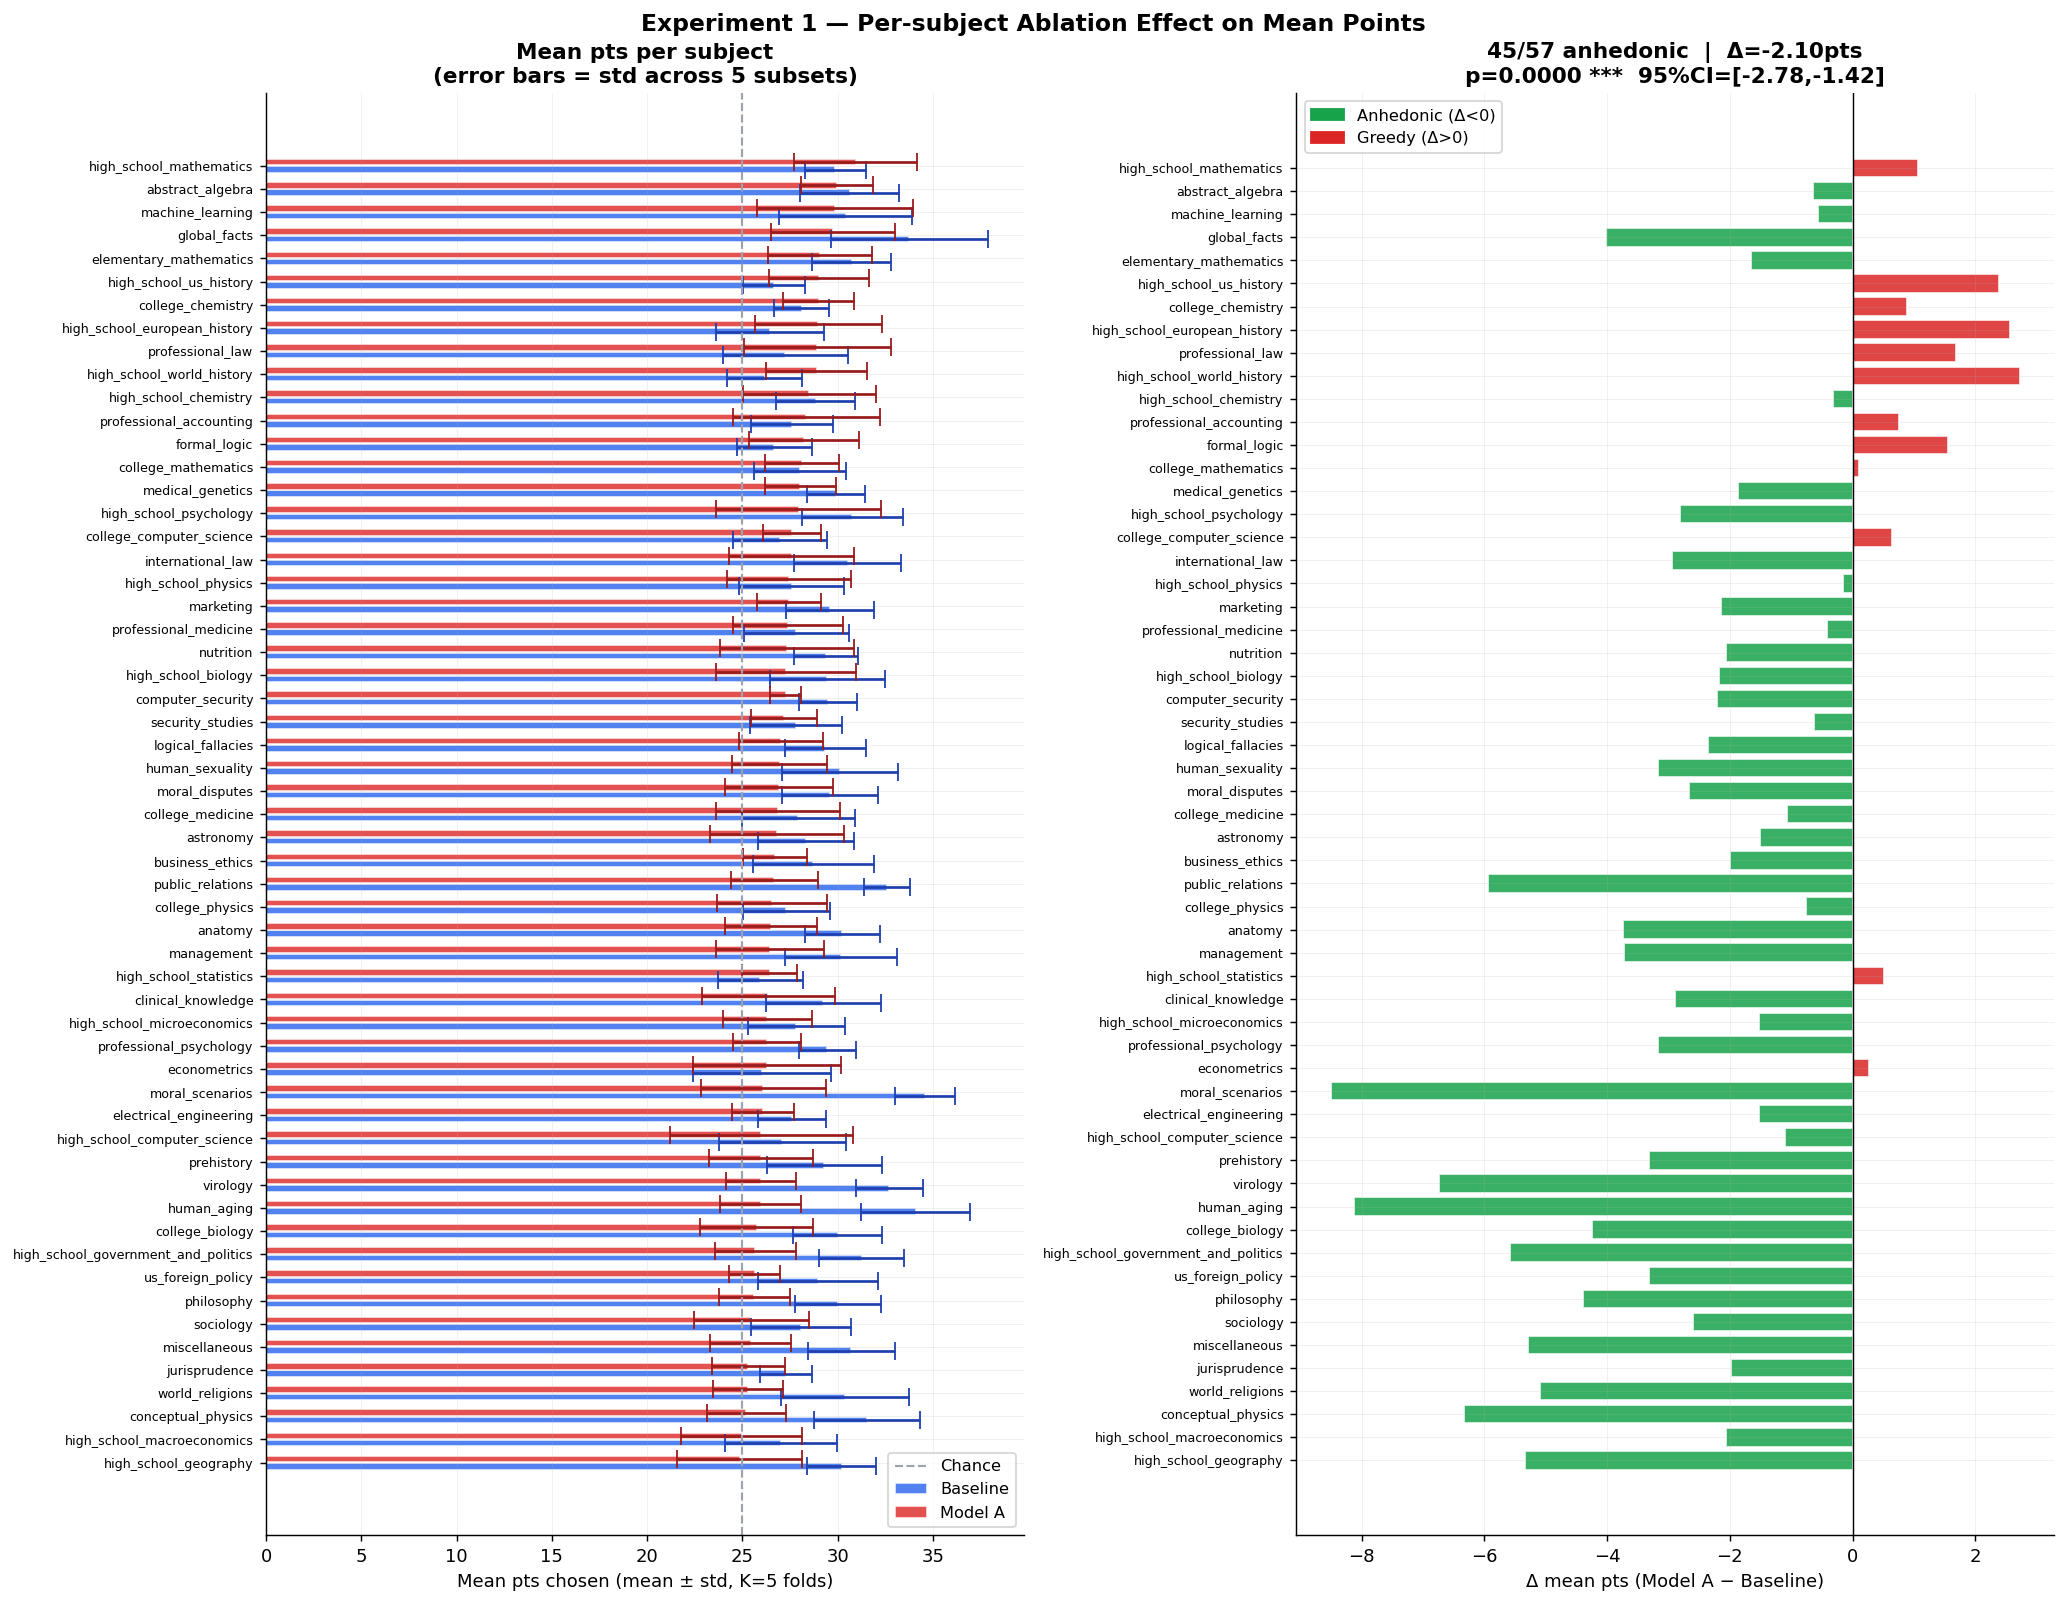

In [5]:
pts = pd.DataFrame({
    'b_mean': e1b.set_index('subject')['mean_pts_mean'],
    'b_std':  e1b.set_index('subject')['mean_pts_std'],
    'a_mean': e1a.set_index('subject')['mean_pts_mean'],
    'a_std':  e1a.set_index('subject')['mean_pts_std'],
}).dropna()
pts['delta'] = pts['a_mean'] - pts['b_mean']
pts = pts.sort_values('a_mean')
y   = np.arange(len(pts))

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(pts)*0.22)))

ax = axes[0]
ax.barh(y-0.16, pts['b_mean'], 0.28, xerr=pts['b_std'], color=BL, alpha=0.8, label='Baseline',
        edgecolor='white', error_kw={'elinewidth':1.5,'capsize':5,'ecolor':'#1e40af'})
ax.barh(y+0.16, pts['a_mean'], 0.28, xerr=pts['a_std'], color=MA, alpha=0.8, label='Model A',
        edgecolor='white', error_kw={'elinewidth':1.5,'capsize':5,'ecolor':'#991b1b'})
ax.axvline(CHANCE_MEAN, color=CH, lw=1.2, ls='--', label='Chance')
ax.set_yticks(y); ax.set_yticklabels(pts.index, fontsize=7)
ax.set_xlabel('Mean pts chosen (mean ± std, K=5 folds)')
ax.set_title('Mean pts per subject\n(error bars = std across 5 subsets)', fontweight='bold')
ax.legend(fontsize=9)

ax2 = axes[1]
dcols = [RB if d<0 else MA for d in pts['delta']]
ax2.barh(y, pts['delta'], color=dcols, alpha=0.85, edgecolor='white')
ax2.axvline(0, color='black', lw=0.8)
ax2.set_yticks(y); ax2.set_yticklabels(pts.index, fontsize=7)
n_anh = (pts['delta']<0).sum()
ax2.set_xlabel('Δ mean pts (Model A − Baseline)')
ax2.set_title(f'{n_anh}/{len(pts)} anhedonic  |  Δ={tt_pts["delta"]:+.2f}pts\n'
              f'p={tt_pts["p1"]:.4f} {sig_stars(tt_pts["p1"])}  95%CI=[{tt_pts["ci"][0]:.2f},{tt_pts["ci"][1]:.2f}]',
              fontweight='bold')
ax2.legend(handles=[mpatches.Patch(color=RB,label='Anhedonic (Δ<0)'),
                    mpatches.Patch(color=MA,label='Greedy (Δ>0)')], fontsize=9)

plt.suptitle('Experiment 1 — Per-subject Ablation Effect on Mean Points', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP1_DIR}/fig_E1_per_subject.png', bbox_inches='tight')
plt.show()

## ④ Exp1 — Stacked choice distribution per subject

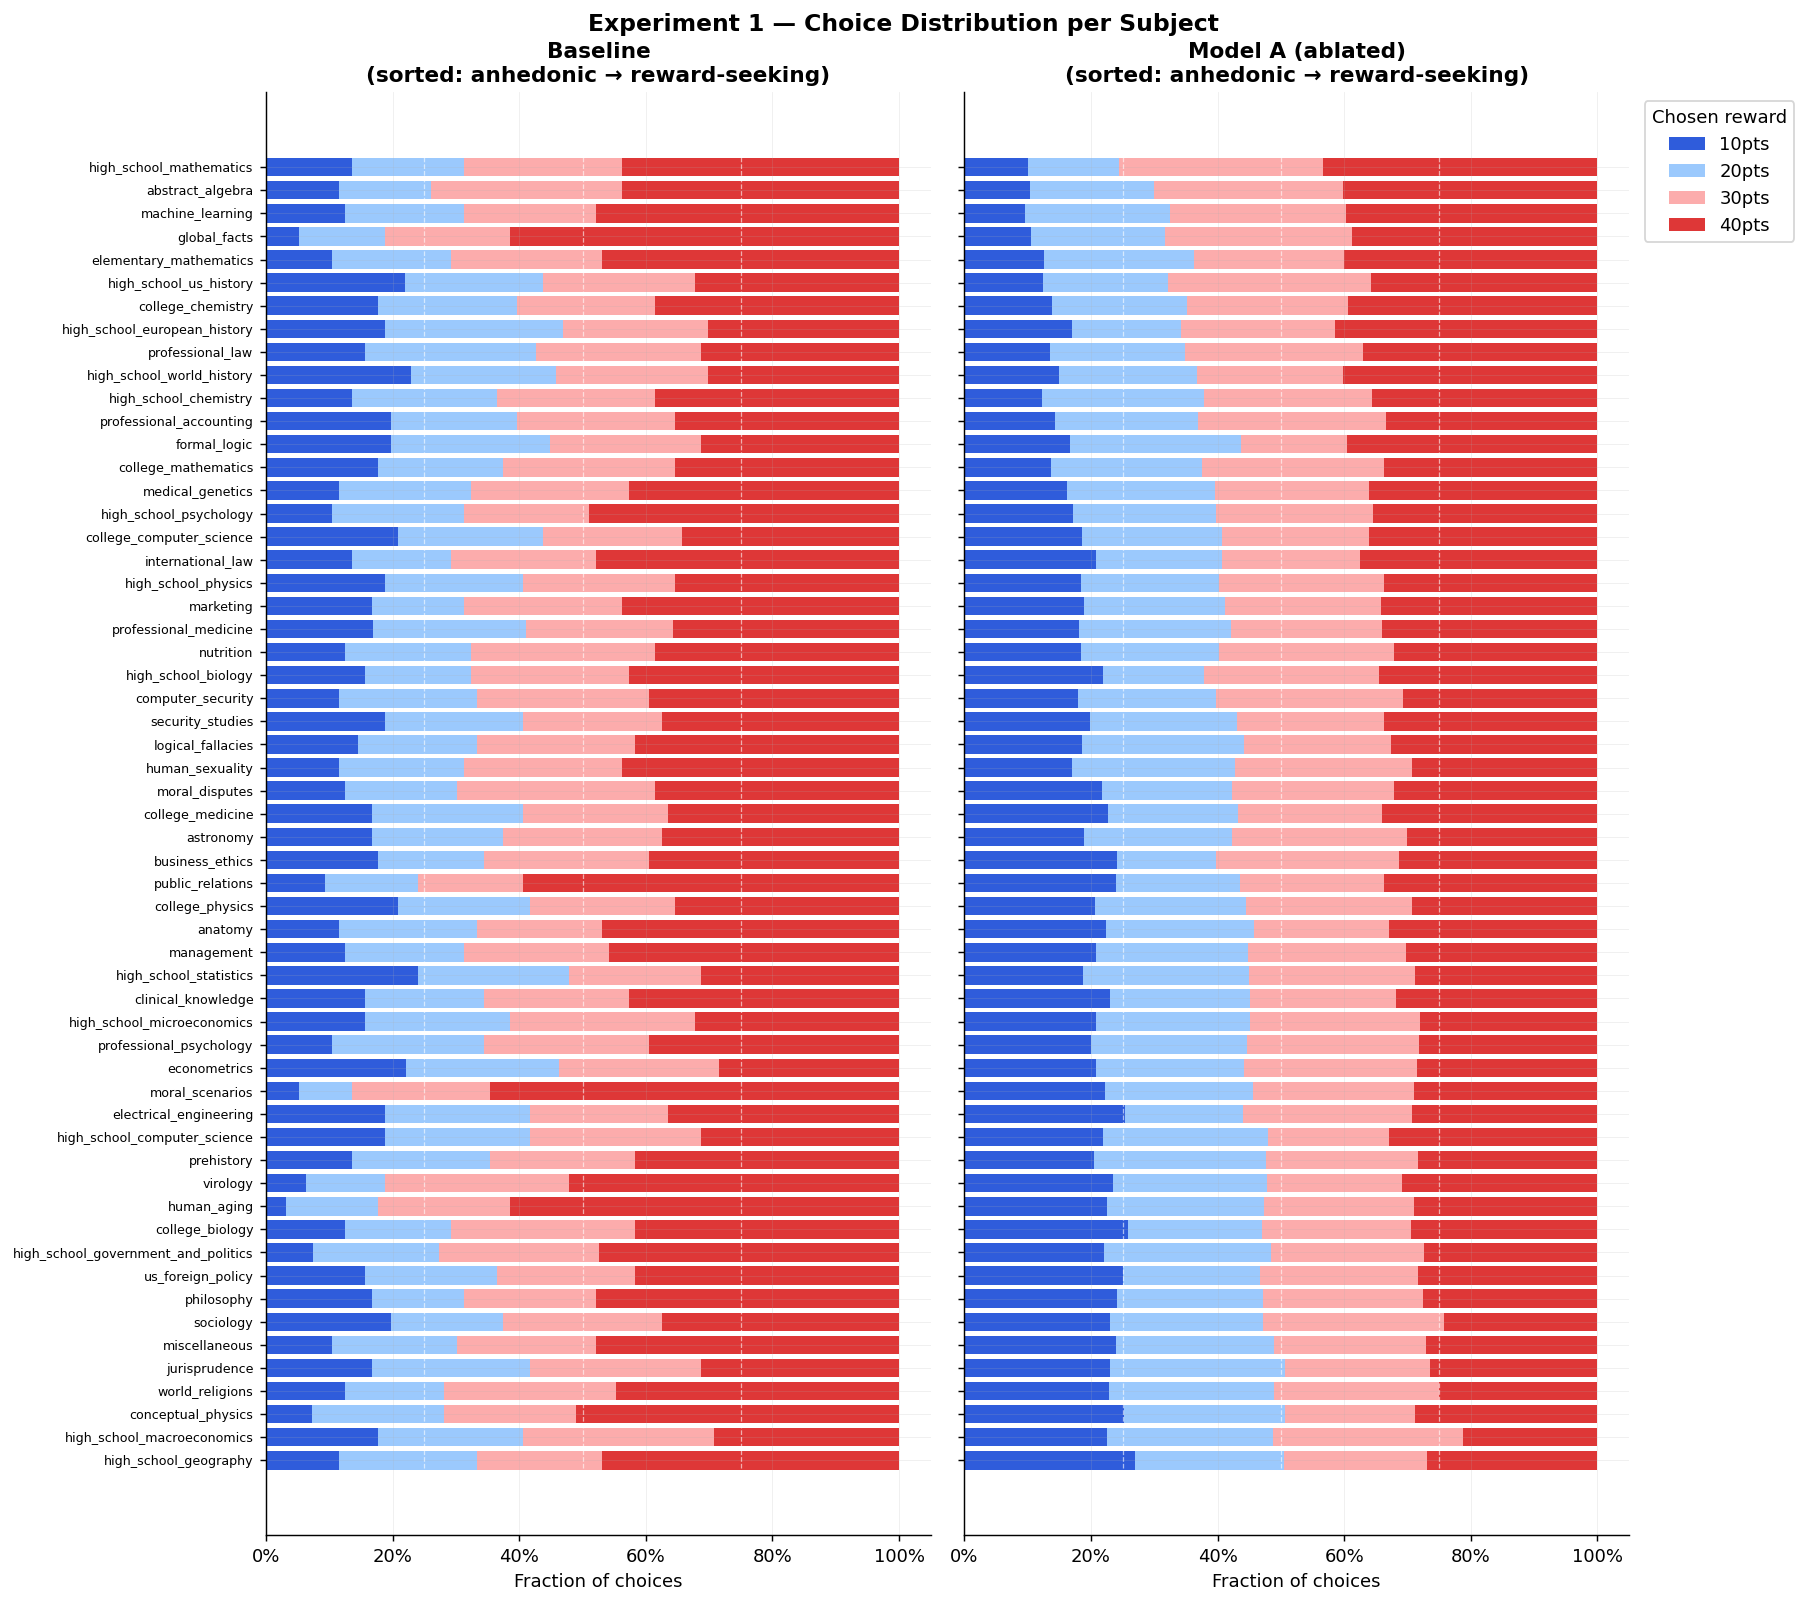

In [6]:
subj_order = pts.index.tolist()
fracs = {}
for tier in ['baseline','model_A']:
    fracs[tier] = {}
    for subj, grp in e1_raw[e1_raw['tier']==tier].groupby('subject'):
        v = grp['chosen_reward'].dropna()
        fracs[tier][subj] = {r:(v==r).mean() for r in REWARD_LEVELS}

cmap = {10:C10,20:C20,30:C30,40:C40}
fig, axes = plt.subplots(1, 2, figsize=(14, max(6,len(subj_order)*0.22)), sharey=True)
for ax, tier, title in [(axes[0],'baseline','Baseline'),(axes[1],'model_A','Model A (ablated)')]:
    fdf  = pd.DataFrame(fracs[tier]).T.reindex(subj_order).fillna(0)
    left = np.zeros(len(fdf))
    for r in REWARD_LEVELS:
        ax.barh(fdf.index, fdf[r].values, left=left, color=cmap[r], label=f'{r}pts', alpha=0.92)
        left += fdf[r].values
    for v in [0.25,0.5,0.75]:
        ax.axvline(v, color='white', lw=0.7, ls='--', alpha=0.6)
    ax.set_xlabel('Fraction of choices')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(f'{title}\n(sorted: anhedonic → reward-seeking)', fontweight='bold')
    ax.tick_params(axis='y', labelsize=7)
axes[1].legend(title='Chosen reward', bbox_to_anchor=(1.01,1), loc='upper left')
plt.suptitle('Experiment 1 — Choice Distribution per Subject', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP1_DIR}/fig_E1_stacked.png', bbox_inches='tight')
plt.show()

## ⑤ Exp1 — 40pt choice rate + error bars

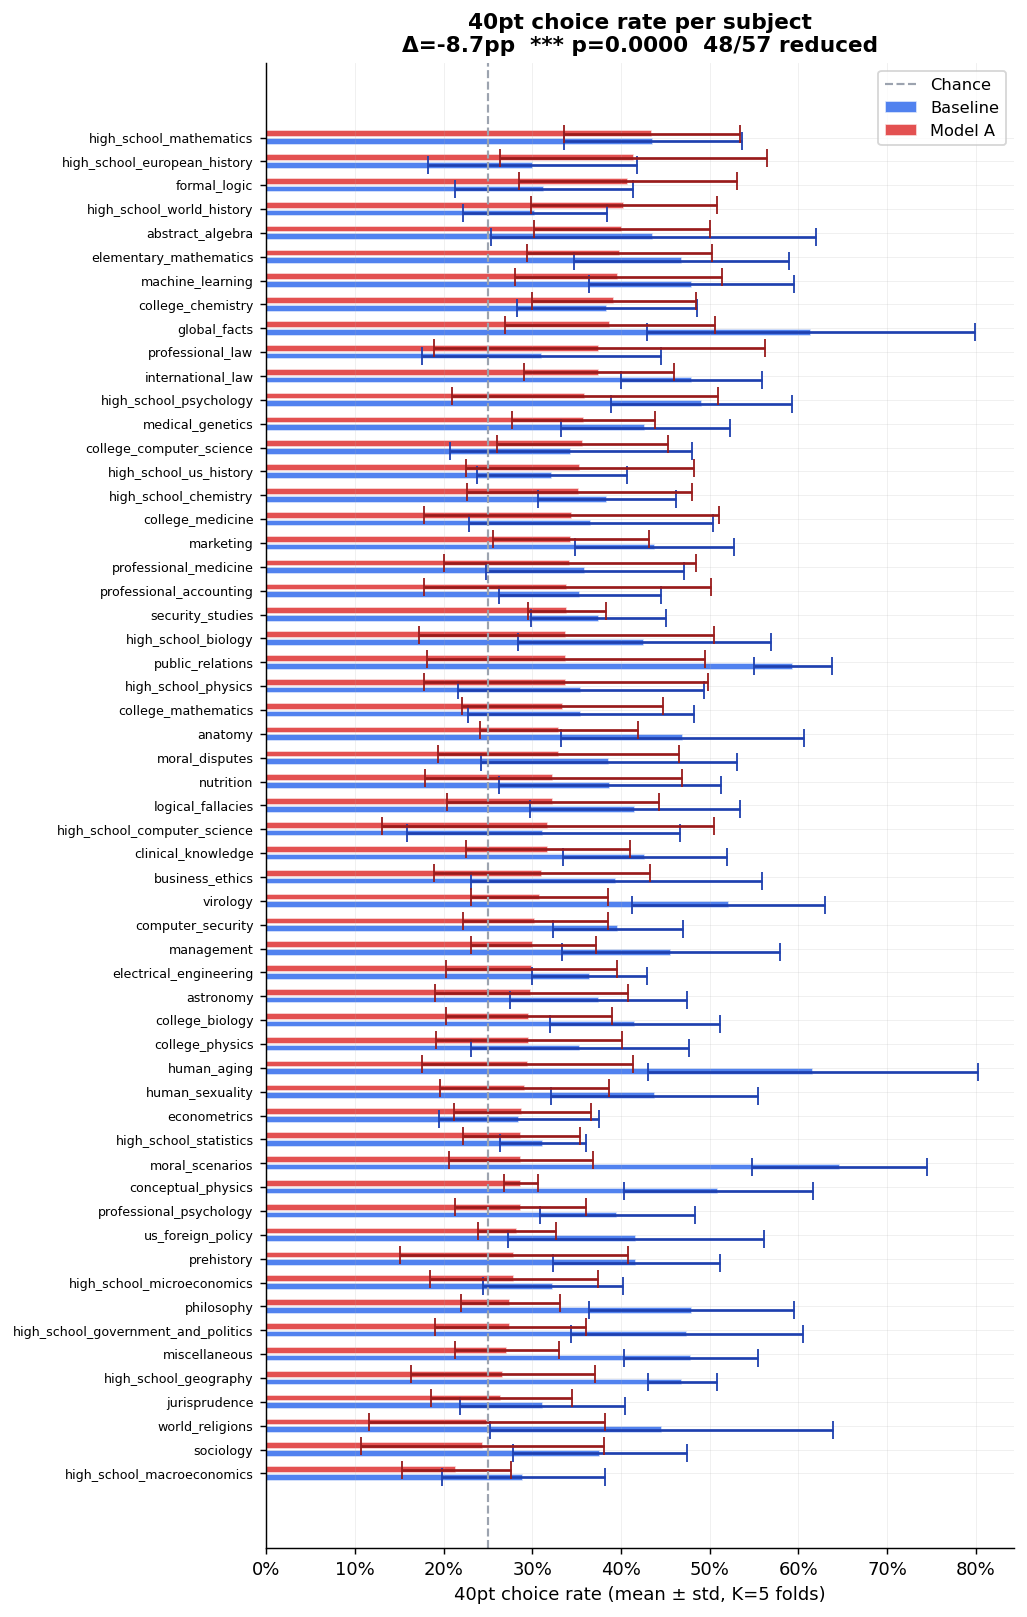

In [7]:
r40b = e1b.set_index('subject')[['rate_40pt_mean','rate_40pt_std']]
r40a = e1a.set_index('subject')[['rate_40pt_mean','rate_40pt_std']]
order40 = r40a.sort_values('rate_40pt_mean').index.tolist()
y = np.arange(len(order40))

fig, ax = plt.subplots(figsize=(8, max(6, len(order40)*0.22)))
ax.barh(y-0.16, r40b.loc[order40,'rate_40pt_mean'], 0.28,
        xerr=r40b.loc[order40,'rate_40pt_std'], color=BL, alpha=0.8, label='Baseline',
        edgecolor='white', error_kw={'elinewidth':1.5,'capsize':5,'ecolor':'#1e40af'})
ax.barh(y+0.16, r40a.loc[order40,'rate_40pt_mean'], 0.28,
        xerr=r40a.loc[order40,'rate_40pt_std'], color=MA, alpha=0.8, label='Model A',
        edgecolor='white', error_kw={'elinewidth':1.5,'capsize':5,'ecolor':'#991b1b'})
ax.axvline(CHANCE_RS, color=CH, lw=1.2, ls='--', label='Chance')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_yticks(y); ax.set_yticklabels(order40, fontsize=7)
ax.set_xlabel('40pt choice rate (mean ± std, K=5 folds)')
n_red = (r40a['rate_40pt_mean'] < r40b['rate_40pt_mean']).sum()
ax.set_title(f'40pt choice rate per subject\n'
             f'Δ={tt_40["delta"]*100:+.1f}pp  {sig_stars(tt_40["p1"])} p={tt_40["p1"]:.4f}  '
             f'{n_red}/{len(r40a)} reduced', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{EXP1_DIR}/fig_E1_40pt_rate.png', bbox_inches='tight')
plt.show()

## ⑥ Exp1 — Per-subject significance vs chance (BH-corrected)

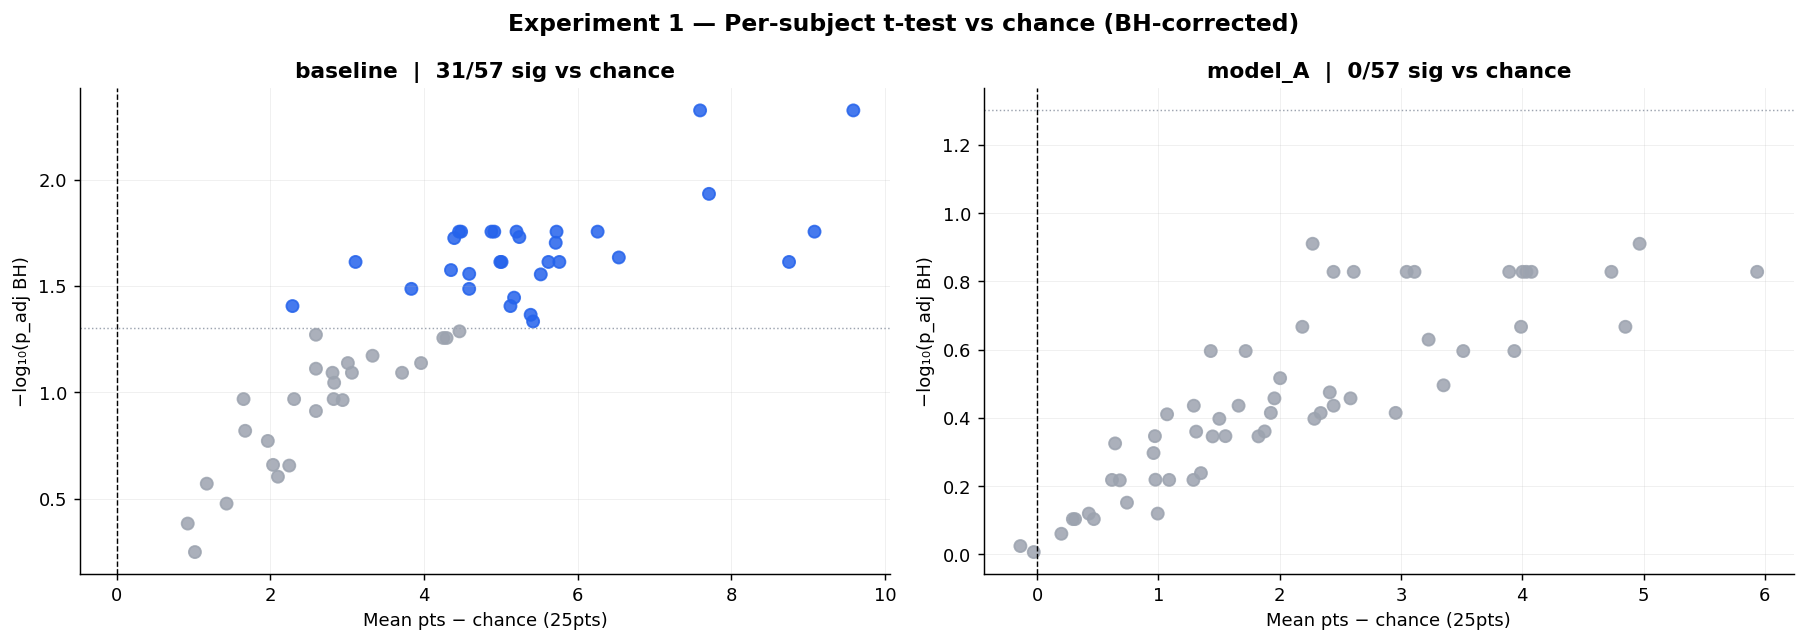

In [8]:
if not e1_subs.empty:
    ttest_rows = []
    for (subj,tier), grp in e1_subs.groupby(['subject','tier']):
        rr = grp['mean_pts'].dropna().values
        if len(rr) >= 2:
            t, p = sp_stats.ttest_1samp(rr, CHANCE_MEAN)
            ttest_rows.append({'subject':subj,'tier':tier,'t':t,'p':p,'mean':rr.mean()})
    tt_df = pd.DataFrame(ttest_rows)
    for tier in ['baseline','model_A']:
        td = tt_df[tt_df['tier']==tier].copy()
        reject, p_adj,_,_ = multipletests(td['p'], method='fdr_bh')
        tt_df.loc[td.index,'p_adj'] = p_adj
        tt_df.loc[td.index,'sig']   = reject

    fig, axes = plt.subplots(1,2, figsize=(14,5))
    for ax, tier, color in [(axes[0],'baseline',BL),(axes[1],'model_A',MA)]:
        td = tt_df[tt_df['tier']==tier]
        pcols = [color if s else CH for s in td['sig']]
        ax.scatter(td['mean']-CHANCE_MEAN, -np.log10(td['p_adj']), c=pcols, s=45, alpha=0.85)
        ax.axvline(0, color='black', lw=0.8, ls='--')
        ax.axhline(-np.log10(0.05), color=CH, lw=0.8, ls=':')
        ax.set_xlabel('Mean pts − chance (25pts)')
        ax.set_ylabel('−log₁₀(p_adj BH)')
        ax.set_title(f'{tier}  |  {int(td["sig"].sum())}/{len(td)} sig vs chance', fontweight='bold')
    plt.suptitle('Experiment 1 — Per-subject t-test vs chance (BH-corrected)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{EXP1_DIR}/fig_E1_significance.png', bbox_inches='tight')
    plt.show()

---
## ⑦ Exp2 — Knowledge accuracy per subject + error bars

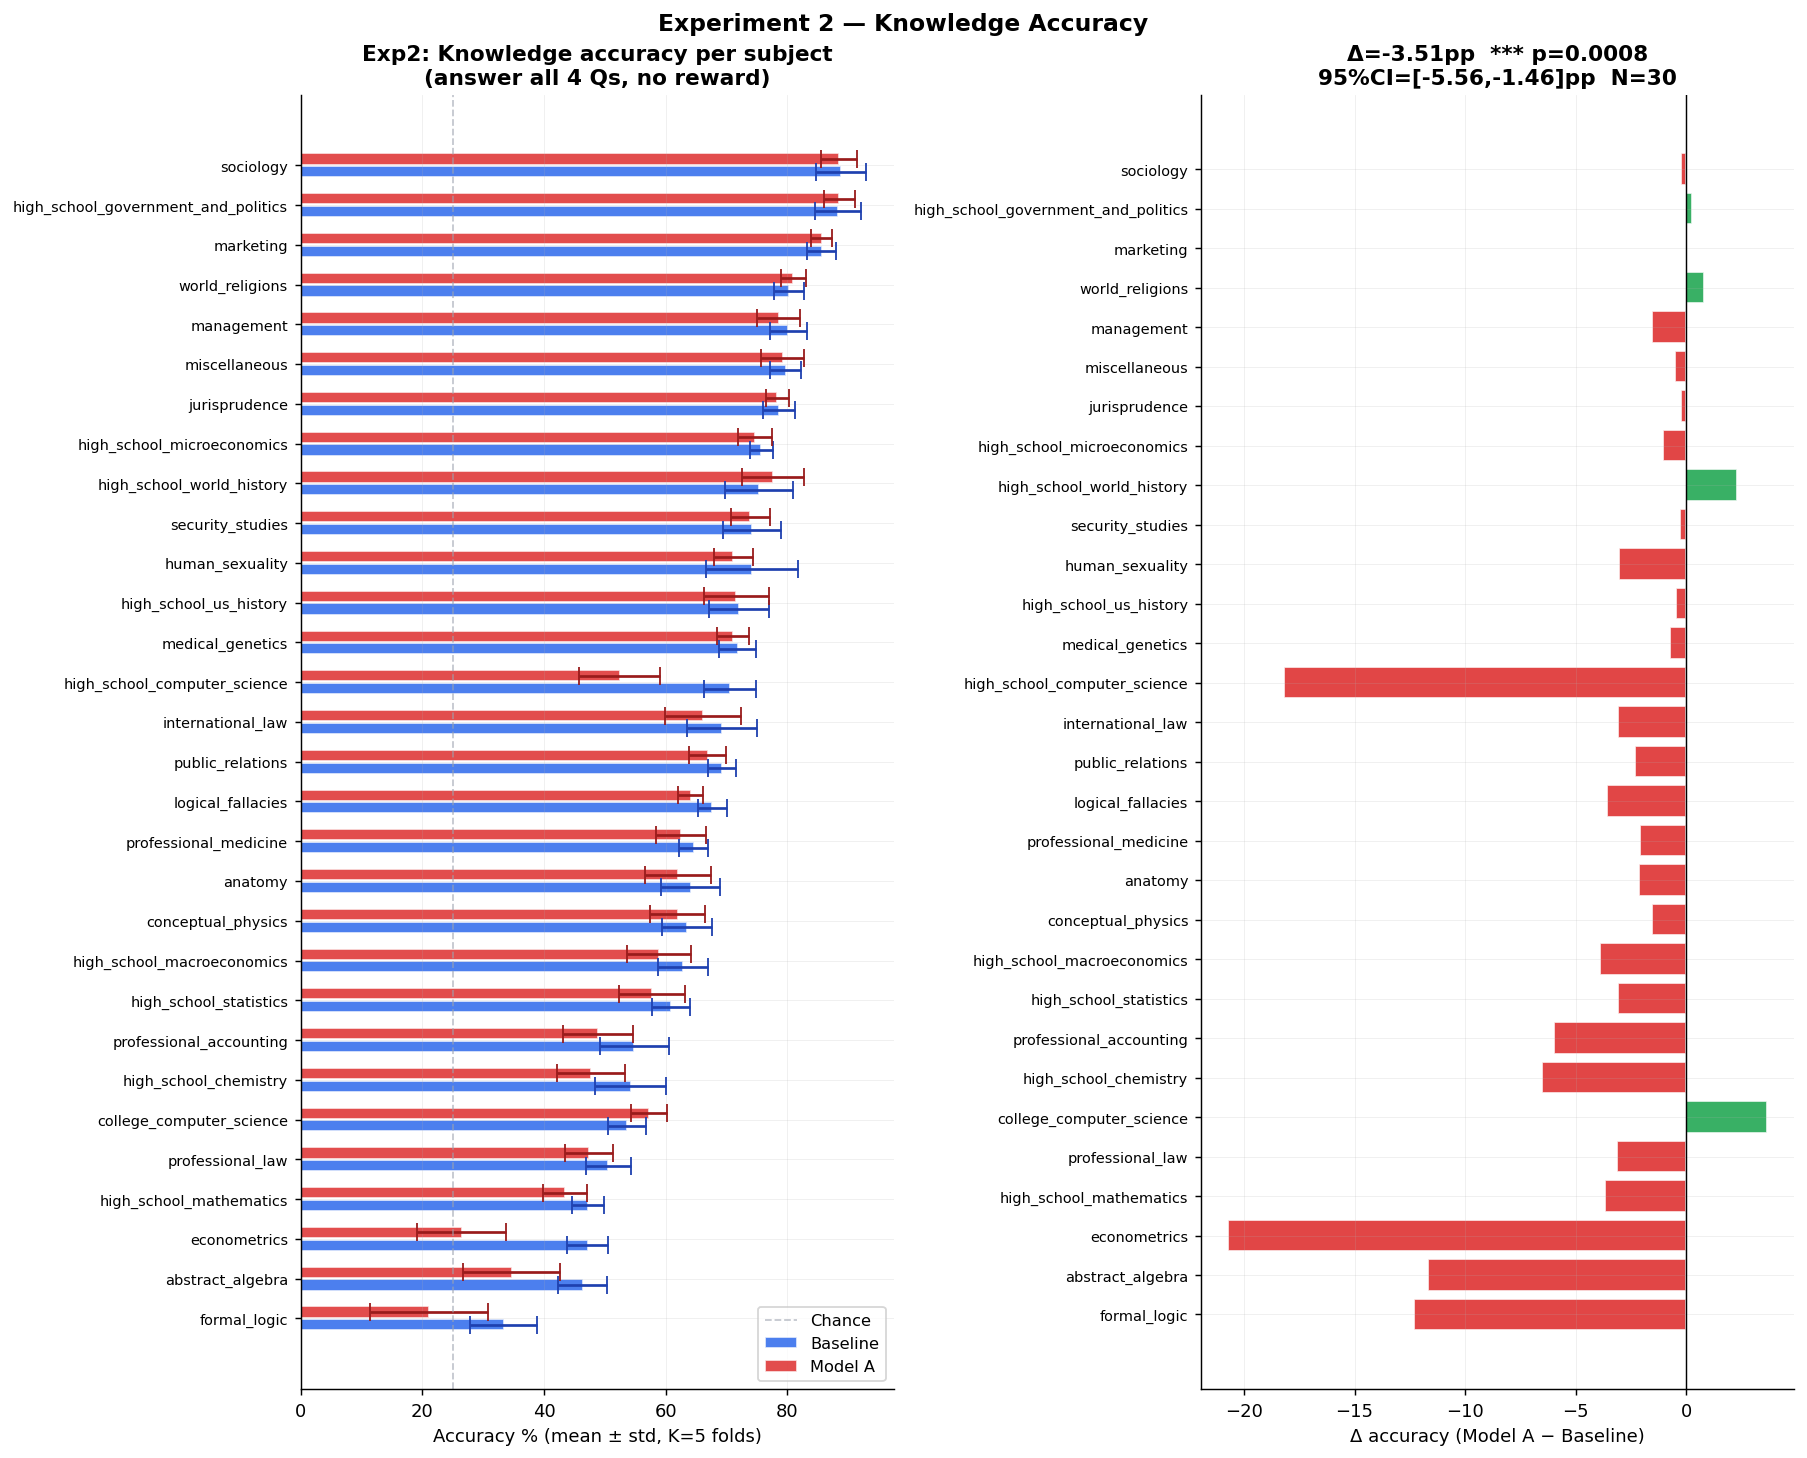

In [9]:
acc2b = e2b.set_index('subject')[['acc_%_mean','acc_%_std']].copy()
acc2a = e2a.set_index('subject')[['acc_%_mean','acc_%_std']].copy()
c2    = acc2b.index.intersection(acc2a.index)
acc2b, acc2a = acc2b.loc[c2], acc2a.loc[c2]
order2 = acc2b['acc_%_mean'].sort_values().index.tolist()
y = np.arange(len(order2))

fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(order2)*0.38)))
ax = axes[0]
ax.barh(y-0.16, acc2b.loc[order2,'acc_%_mean'], 0.28,
        xerr=acc2b.loc[order2,'acc_%_std'], color=BL, alpha=0.82, label='Baseline',
        edgecolor='white', error_kw={'elinewidth':1.5,'capsize':5,'ecolor':'#1e40af'})
ax.barh(y+0.16, acc2a.loc[order2,'acc_%_mean'], 0.28,
        xerr=acc2a.loc[order2,'acc_%_std'], color=MA, alpha=0.82, label='Model A',
        edgecolor='white', error_kw={'elinewidth':1.5,'capsize':5,'ecolor':'#991b1b'})
ax.axvline(25, color=CH, lw=1, ls='--', alpha=0.6, label='Chance')
ax.set_yticks(y); ax.set_yticklabels(order2, fontsize=8)
ax.set_xlabel('Accuracy % (mean ± std, K=5 folds)')
ax.set_title('Exp2: Knowledge accuracy per subject\n(answer all 4 Qs, no reward)', fontweight='bold')
ax.legend(fontsize=9)

ax2 = axes[1]
d2 = acc2a.loc[order2,'acc_%_mean'] - acc2b.loc[order2,'acc_%_mean']
ax2.barh(y, d2, color=[RB if v>=0 else MA for v in d2], alpha=0.85, edgecolor='white')
ax2.axvline(0, color='black', lw=0.8)
ax2.set_yticks(y); ax2.set_yticklabels(order2, fontsize=8)
ax2.set_xlabel('Δ accuracy (Model A − Baseline)')
ax2.set_title(f'Δ={tt_acc2["delta"]:+.2f}pp  {sig_stars(tt_acc2["p1"])} p={tt_acc2["p1"]:.4f}\n'
              f'95%CI=[{tt_acc2["ci"][0]:.2f},{tt_acc2["ci"][1]:.2f}]pp  N={tt_acc2["n"]}',
              fontweight='bold')
plt.suptitle('Experiment 2 — Knowledge Accuracy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP2_DIR}/fig_E2_accuracy.png', bbox_inches='tight')
plt.show()

## ⑧ Exp2 — Accuracy by difficulty tier + p-values

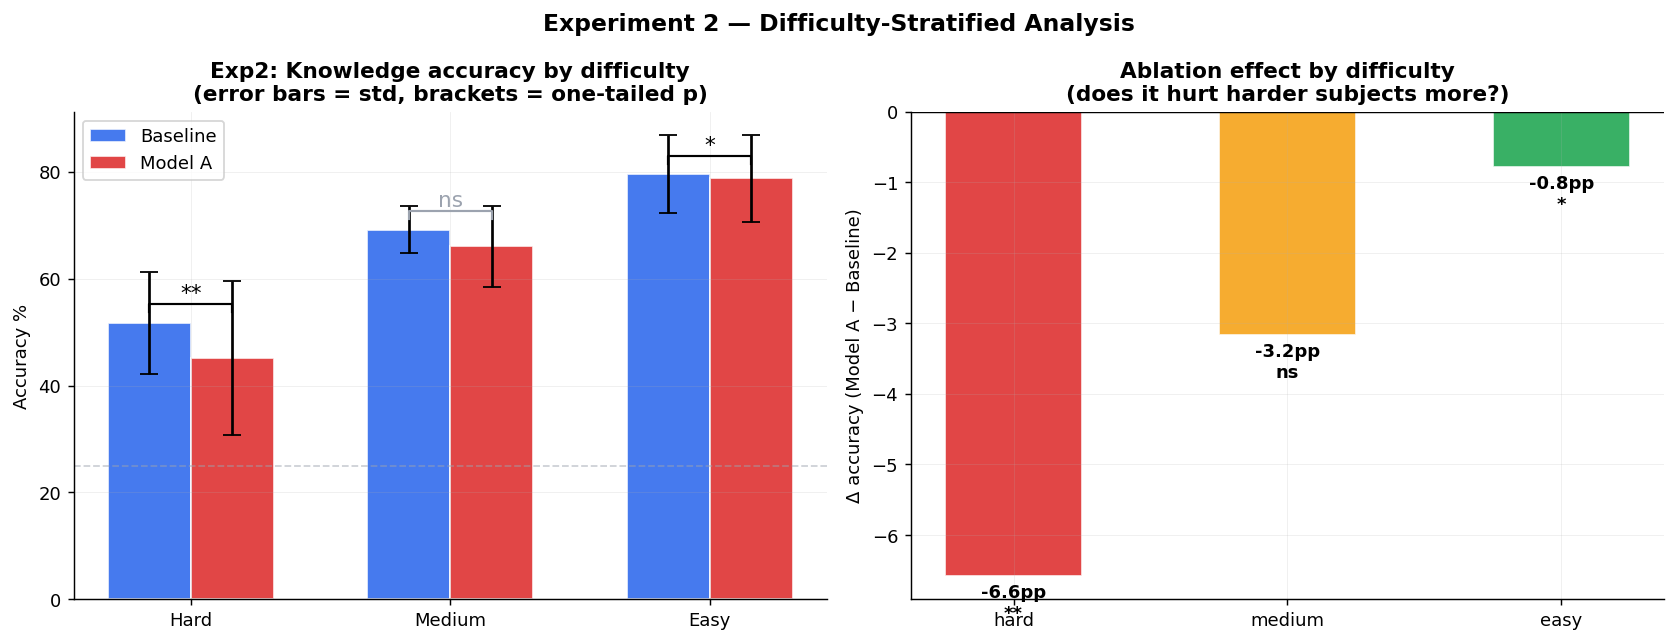

  hard    : Δ=-6.58pp  p=0.0067 **
  medium  : Δ=-3.17pp  p=0.0534 ns
  easy    : Δ=-0.78pp  p=0.0318 *


In [10]:
diff_tiers = ['hard','medium','easy']
diff_cols  = {'hard':'#DC2626','medium':'#F59E0B','easy':'#16A34A'}
x, w = np.arange(3), 0.32

bm = [e2b[e2b['difficulty_tier']==d]['acc_%_mean'].mean() for d in diff_tiers]
am = [e2a[e2a['difficulty_tier']==d]['acc_%_mean'].mean() for d in diff_tiers]
bs = [e2b[e2b['difficulty_tier']==d]['acc_%_mean'].std()  for d in diff_tiers]
as_= [e2a[e2a['difficulty_tier']==d]['acc_%_mean'].std()  for d in diff_tiers]

tier_p = []
for d in diff_tiers:
    bv = e2b[e2b['difficulty_tier']==d].set_index('subject')['acc_%_mean']
    av = e2a[e2a['difficulty_tier']==d].set_index('subject')['acc_%_mean']
    c  = bv.index.intersection(av.index)
    if len(c) >= 2:
        _, p = sp_stats.ttest_rel(av.loc[c].values, bv.loc[c].values, alternative='less')
    else: p = 1.0
    tier_p.append(p)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.bar(x-w/2, bm, w, yerr=bs, color=BL, alpha=0.85, label='Baseline',
       error_kw={'elinewidth':1.5,'capsize':5}, edgecolor='white')
ax.bar(x+w/2, am, w, yerr=as_, color=MA, alpha=0.85, label='Model A',
       error_kw={'elinewidth':1.5,'capsize':5}, edgecolor='white')
ax.axhline(25, color=CH, lw=1, ls='--', alpha=0.5)
for i,(p,b,a) in enumerate(zip(tier_p,bm,am)):
    add_bracket(ax, i-w/2, i+w/2, max(b,a)+2, p, h=1.5, fs=12)
ax.set_xticks(x); ax.set_xticklabels(['Hard','Medium','Easy'])
ax.set_ylabel('Accuracy %'); ax.legend()
ax.set_title('Exp2: Knowledge accuracy by difficulty\n(error bars = std, brackets = one-tailed p)', fontweight='bold')

ax2 = axes[1]
deltas = [a-b for a,b in zip(am,bm)]
bars = ax2.bar(diff_tiers, deltas, color=[diff_cols[t] for t in diff_tiers], alpha=0.85, edgecolor='white', width=0.5)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_ylabel('Δ accuracy (Model A − Baseline)')
ax2.set_title('Ablation effect by difficulty\n(does it hurt harder subjects more?)', fontweight='bold')
for bar, d, p in zip(bars, deltas, tier_p):
    ax2.text(bar.get_x()+bar.get_width()/2, d+(0.3 if d>=0 else -0.6),
             f'{d:+.1f}pp\n{sig_stars(p)}', ha='center', fontweight='bold', fontsize=10)
plt.suptitle('Experiment 2 — Difficulty-Stratified Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP2_DIR}/fig_E2_difficulty.png', bbox_inches='tight')
plt.show()
for d, delta, p in zip(diff_tiers, deltas, tier_p):
    print(f'  {d:<8}: Δ={delta:+.2f}pp  p={p:.4f} {sig_stars(p)}')

---
## ⑨ Exp3 — Robustness: single-question MMLU, all 57 subjects

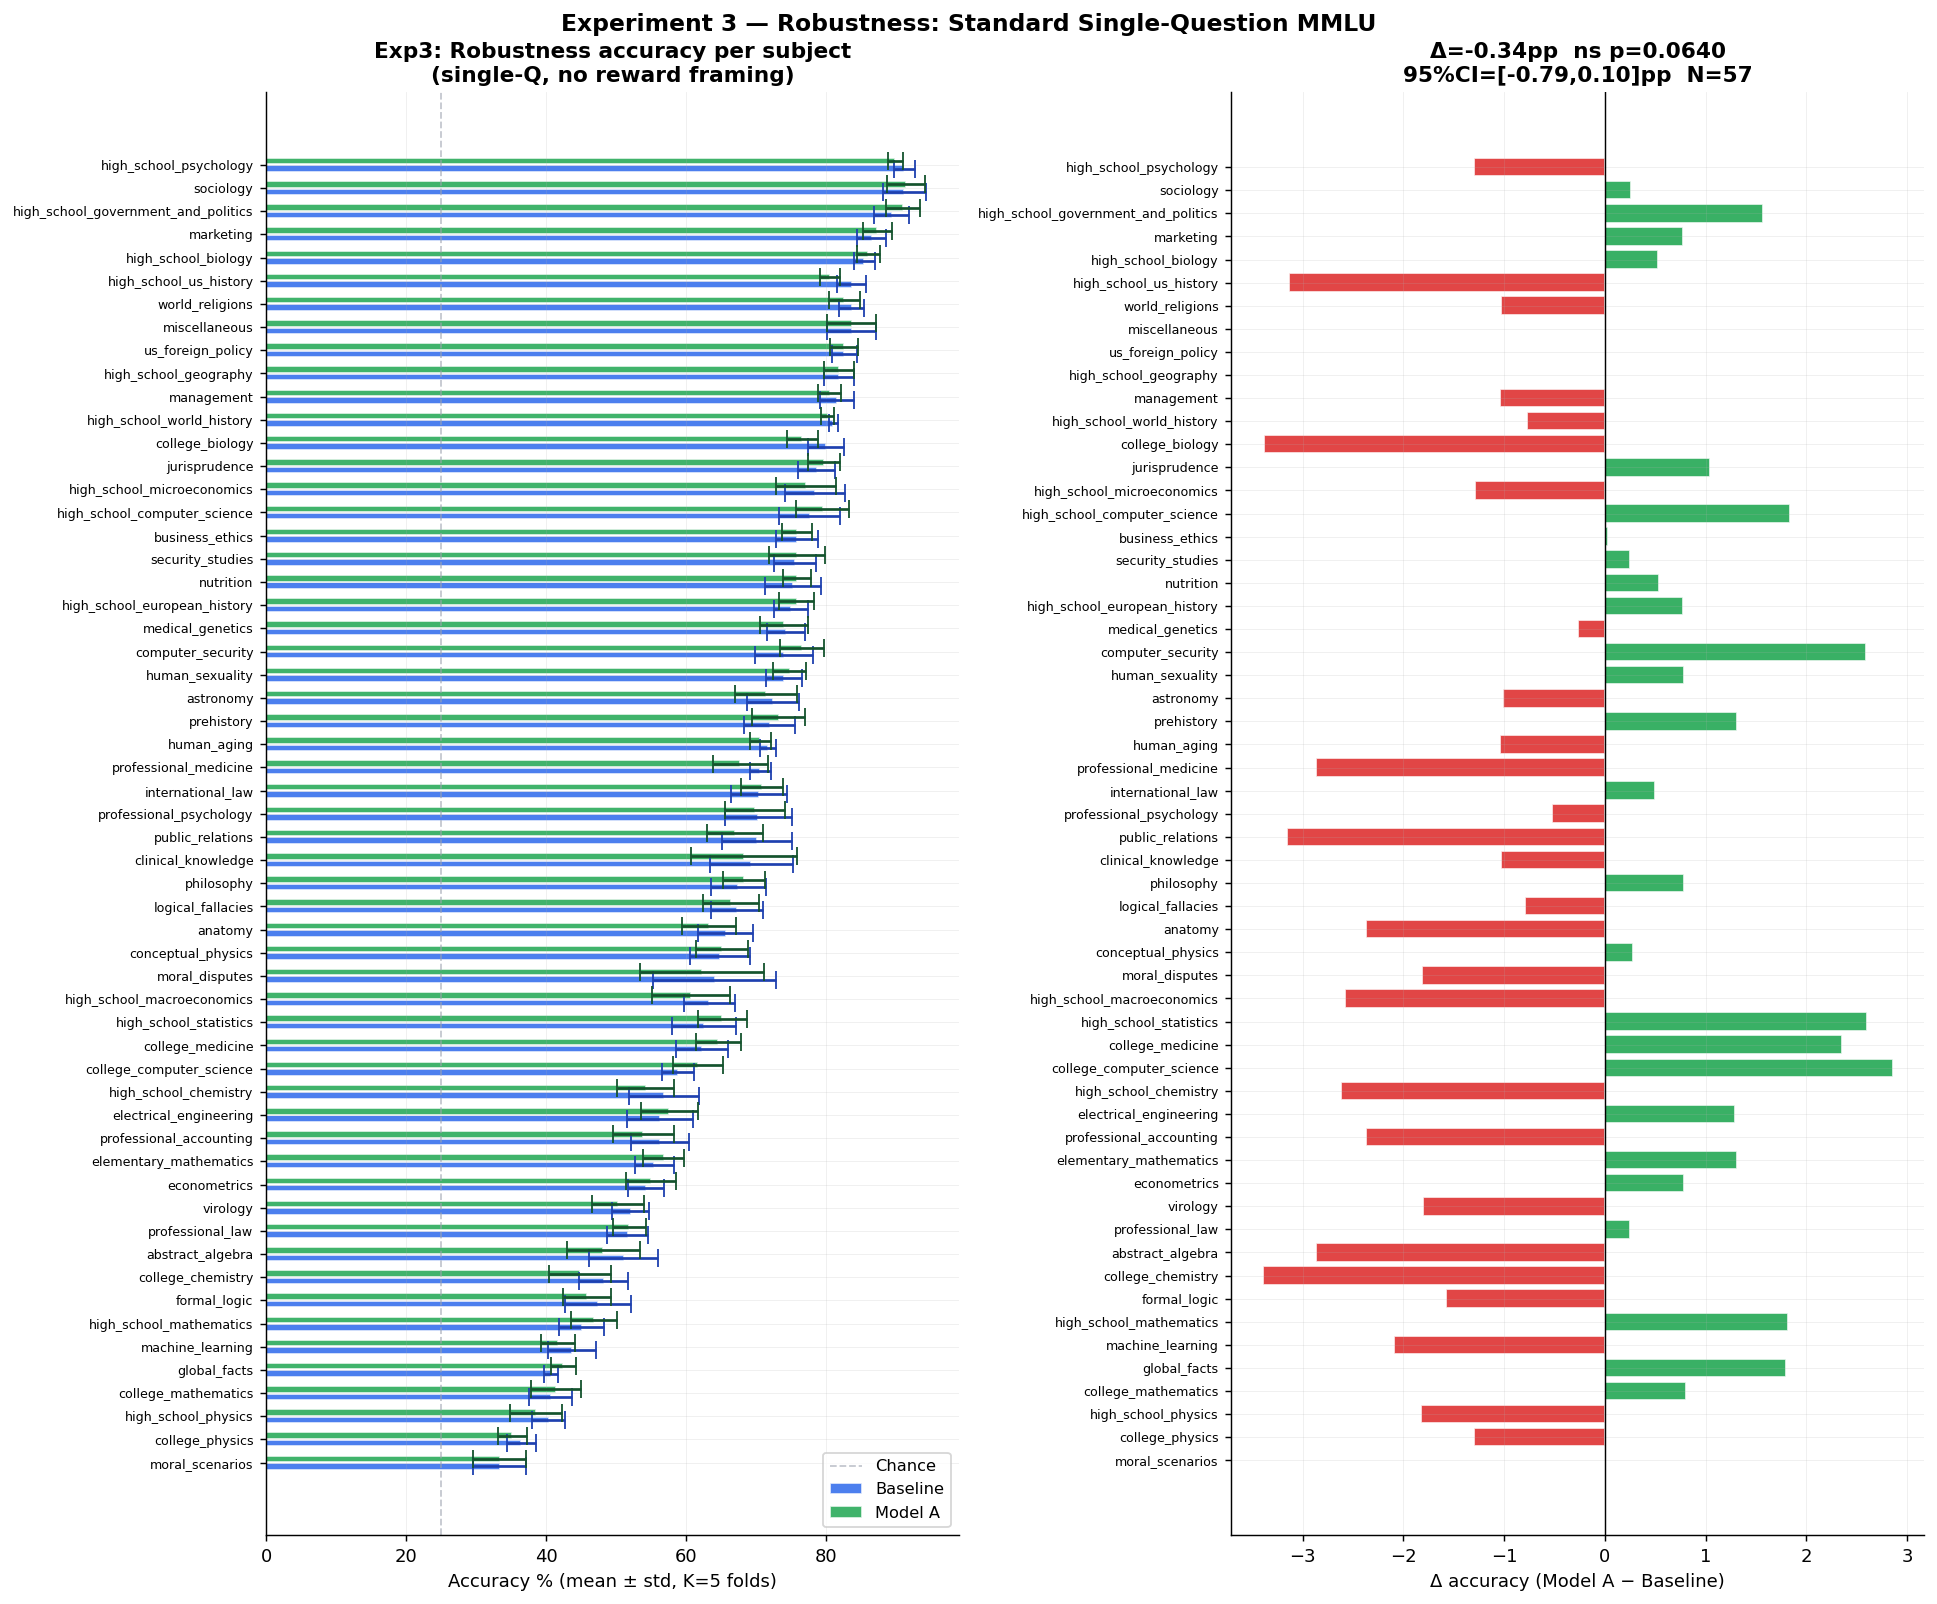

In [11]:
acc3b = e3b.set_index('subject')[['acc_%_mean','acc_%_std']].copy()
acc3a = e3a.set_index('subject')[['acc_%_mean','acc_%_std']].copy()
c3    = acc3b.index.intersection(acc3a.index)
acc3b, acc3a = acc3b.loc[c3], acc3a.loc[c3]
order3 = acc3b['acc_%_mean'].sort_values().index.tolist()
y = np.arange(len(order3))

fig, axes = plt.subplots(1, 2, figsize=(15, max(6, len(order3)*0.22)))
ax = axes[0]
ax.barh(y-0.16, acc3b.loc[order3,'acc_%_mean'], 0.28,
        xerr=acc3b.loc[order3,'acc_%_std'], color=BL, alpha=0.82, label='Baseline',
        edgecolor='white', error_kw={'elinewidth':1.5,'capsize':5,'ecolor':'#1e40af'})
ax.barh(y+0.16, acc3a.loc[order3,'acc_%_mean'], 0.28,
        xerr=acc3a.loc[order3,'acc_%_std'], color=RB, alpha=0.82, label='Model A',
        edgecolor='white', error_kw={'elinewidth':1.5,'capsize':5,'ecolor':'#14532d'})
ax.axvline(25, color=CH, lw=1, ls='--', alpha=0.6, label='Chance')
ax.set_yticks(y); ax.set_yticklabels(order3, fontsize=7)
ax.set_xlabel('Accuracy % (mean ± std, K=5 folds)')
ax.set_title('Exp3: Robustness accuracy per subject\n(single-Q, no reward framing)', fontweight='bold')
ax.legend(fontsize=9)

ax2 = axes[1]
d3 = acc3a.loc[order3,'acc_%_mean'] - acc3b.loc[order3,'acc_%_mean']
ax2.barh(y, d3, color=[RB if v>=0 else MA for v in d3], alpha=0.85, edgecolor='white')
ax2.axvline(0, color='black', lw=0.8)
ax2.set_yticks(y); ax2.set_yticklabels(order3, fontsize=7)
ax2.set_xlabel('Δ accuracy (Model A − Baseline)')
ax2.set_title(f'Δ={tt_acc3["delta"]:+.2f}pp  {sig_stars(tt_acc3["p1"])} p={tt_acc3["p1"]:.4f}\n'
              f'95%CI=[{tt_acc3["ci"][0]:.2f},{tt_acc3["ci"][1]:.2f}]pp  N={tt_acc3["n"]}',
              fontweight='bold')
plt.suptitle('Experiment 3 — Robustness: Standard Single-Question MMLU', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP3_DIR}/fig_E3_robustness.png', bbox_inches='tight')
plt.show()

---
## ⑩ COMBINED — All three experiments in one figure

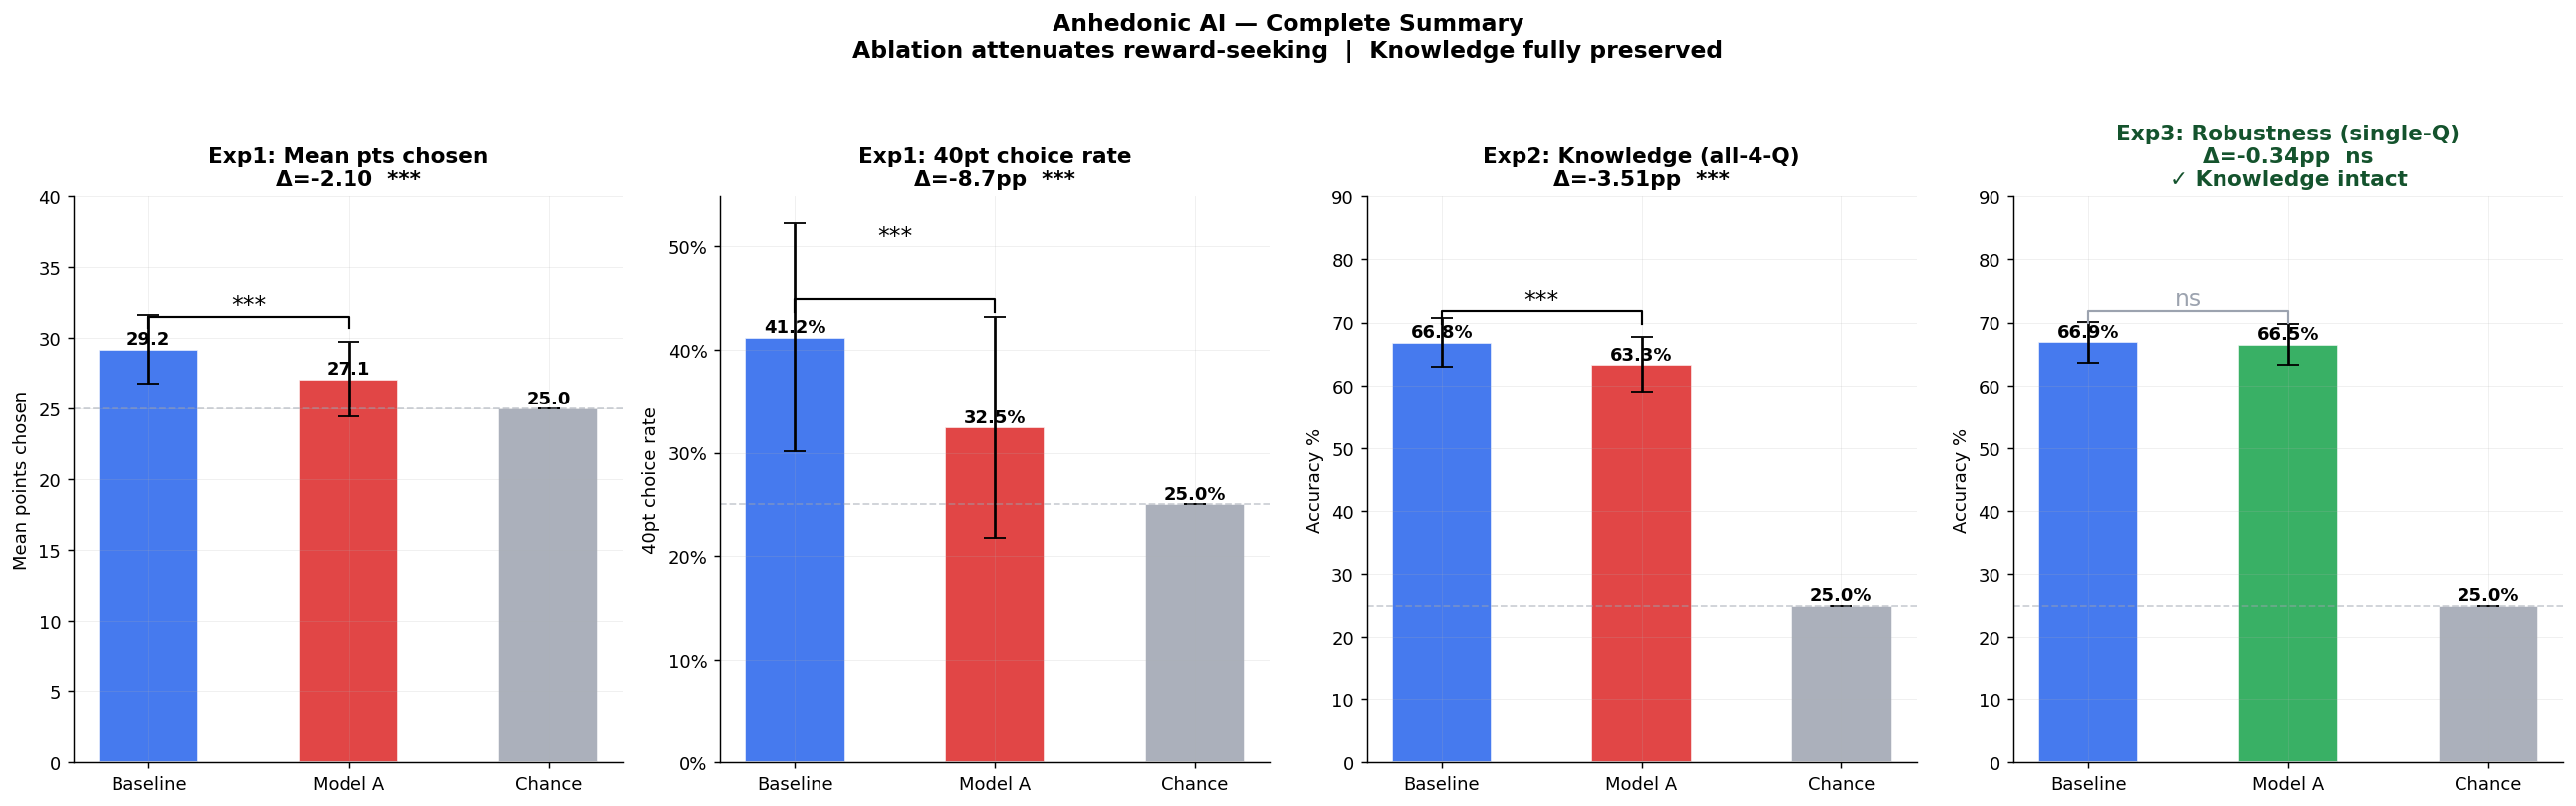

COMPLETE SUMMARY
  Metric                                 Baseline    Model A         Δ         p  Sig
  ───────────────────────────────────────────────────────────────────────────
  Exp1  Mean pts chosen                     29.20      27.10     -2.10    0.0000  ***
  Exp1  40pt choice rate                    41.2%      32.5%     -8.7pp    0.0000  ***
  Exp2  Knowledge acc (all-4-Q)            66.84%     63.33%    -3.51pp    0.0008  ***
  Exp3  Robustness acc (single-Q)          66.86%     66.52%    -0.34pp    0.0640  ns


In [12]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
cats = ['Baseline','Model A','Chance']
cols = [BL, MA, CH]

# ── Panel 1: Mean pts ──────────────────────────────────────────────────────
ax = axes[0]
mp = [e1b['mean_pts_mean'].mean(), e1a['mean_pts_mean'].mean(), CHANCE_MEAN]
ms = [e1b['mean_pts_std'].mean(),  e1a['mean_pts_std'].mean(),  0]
bars = ax.bar(cats, mp, yerr=ms, color=cols, alpha=0.85, edgecolor='white', width=0.5,
              error_kw={'elinewidth':1.5,'capsize':6})
ax.axhline(CHANCE_MEAN, color=CH, lw=1, ls='--', alpha=0.5)
ax.set_ylim(0, 40); ax.set_ylabel('Mean points chosen')
for bar,v in zip(bars,mp):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.4, f'{v:.1f}', ha='center', fontweight='bold')
add_bracket(ax, 0, 1, max(mp[:2])+1.5, tt_pts['p1'], h=0.8, fs=13)
ax.set_title(f'Exp1: Mean pts chosen\nΔ={tt_pts["delta"]:+.2f}  {sig_stars(tt_pts["p1"])}', fontweight='bold')

# ── Panel 2: 40pt rate ─────────────────────────────────────────────────────
ax2 = axes[1]
rp = [e1b['rate_40pt_mean'].mean(), e1a['rate_40pt_mean'].mean(), CHANCE_RS]
rs = [e1b['rate_40pt_std'].mean(),  e1a['rate_40pt_std'].mean(),  0]
bars2 = ax2.bar(cats, rp, yerr=rs, color=cols, alpha=0.85, edgecolor='white', width=0.5,
                error_kw={'elinewidth':1.5,'capsize':6})
ax2.axhline(CHANCE_RS, color=CH, lw=1, ls='--', alpha=0.5)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_ylabel('40pt choice rate')
for bar,v in zip(bars2,rp):
    ax2.text(bar.get_x()+bar.get_width()/2, v+0.005, f'{v:.1%}', ha='center', fontweight='bold')
add_bracket(ax2, 0, 1, max(rp[:2])+0.025, tt_40['p1'], h=0.012, fs=13)
ax2.set_title(f'Exp1: 40pt choice rate\nΔ={tt_40["delta"]*100:+.1f}pp  {sig_stars(tt_40["p1"])}', fontweight='bold')

# ── Panel 3: Knowledge accuracy (Exp2 all-4-Q) ────────────────────────────
ax3 = axes[2]
ap2 = [e2b['acc_%_mean'].mean(), e2a['acc_%_mean'].mean(), 25.0]
as2 = [e2b['acc_%_std'].mean(),  e2a['acc_%_std'].mean(),  0]
bars3 = ax3.bar(cats, ap2, yerr=as2, color=cols, alpha=0.85, edgecolor='white', width=0.5,
                error_kw={'elinewidth':1.5,'capsize':6})
ax3.axhline(25, color=CH, lw=1, ls='--', alpha=0.5)
ax3.set_ylim(0, 90); ax3.set_ylabel('Accuracy %')
for bar,v in zip(bars3,ap2):
    ax3.text(bar.get_x()+bar.get_width()/2, v+0.8, f'{v:.1f}%', ha='center', fontweight='bold')
add_bracket(ax3, 0, 1, max(ap2[:2])+3, tt_acc2['p1'], h=2, fs=13)
ax3.set_title(f'Exp2: Knowledge (all-4-Q)\nΔ={tt_acc2["delta"]:+.2f}pp  {sig_stars(tt_acc2["p1"])}', fontweight='bold')

# ── Panel 4: Robustness accuracy (Exp3 single-Q) ──────────────────────────
ax4 = axes[3]
ap3 = [e3b['acc_%_mean'].mean(), e3a['acc_%_mean'].mean(), 25.0]
as3 = [e3b['acc_%_std'].mean(),  e3a['acc_%_std'].mean(),  0]
# Use green for Model A here to visually signal 'intact'
cols_r = [BL, RB, CH]
bars4 = ax4.bar(cats, ap3, yerr=as3, color=cols_r, alpha=0.85, edgecolor='white', width=0.5,
                error_kw={'elinewidth':1.5,'capsize':6})
ax4.axhline(25, color=CH, lw=1, ls='--', alpha=0.5)
ax4.set_ylim(0, 90); ax4.set_ylabel('Accuracy %')
for bar,v in zip(bars4,ap3):
    ax4.text(bar.get_x()+bar.get_width()/2, v+0.8, f'{v:.1f}%', ha='center', fontweight='bold')
add_bracket(ax4, 0, 1, max(ap3[:2])+3, tt_acc3['p1'], h=2, fs=13)
ax4.set_title(f'Exp3: Robustness (single-Q)\nΔ={tt_acc3["delta"]:+.2f}pp  {sig_stars(tt_acc3["p1"])}\n✓ Knowledge intact',
              fontweight='bold', color='#14532d')

plt.suptitle(
    'Anhedonic AI — Complete Summary\n'
    'Ablation attenuates reward-seeking  |  Knowledge fully preserved',
    fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f'{EXP1_DIR}/fig_COMBINED_all.png', bbox_inches='tight', dpi=150)
plt.show()

print('=' * 68)
print('COMPLETE SUMMARY')
print('=' * 68)
print(f'  {"Metric":<36} {"Baseline":>10} {"Model A":>10} {"Δ":>9}  {"p":>8}  {"Sig"}')
print(f'  {"─"*75}')
print(f'  {"Exp1  Mean pts chosen":<36} {e1b["mean_pts_mean"].mean():>10.2f} {e1a["mean_pts_mean"].mean():>10.2f} {tt_pts["delta"]:>+9.2f}  {tt_pts["p1"]:>8.4f}  {sig_stars(tt_pts["p1"])}')
print(f'  {"Exp1  40pt choice rate":<36} {e1b["rate_40pt_mean"].mean()*100:>9.1f}% {e1a["rate_40pt_mean"].mean()*100:>9.1f}% {tt_40["delta"]*100:>+8.1f}pp  {tt_40["p1"]:>8.4f}  {sig_stars(tt_40["p1"])}')
print(f'  {"Exp2  Knowledge acc (all-4-Q)":<36} {e2b["acc_%_mean"].mean():>9.2f}% {e2a["acc_%_mean"].mean():>9.2f}% {tt_acc2["delta"]:>+8.2f}pp  {tt_acc2["p1"]:>8.4f}  {sig_stars(tt_acc2["p1"])}')
print(f'  {"Exp3  Robustness acc (single-Q)":<36} {e3b["acc_%_mean"].mean():>9.2f}% {e3a["acc_%_mean"].mean():>9.2f}% {tt_acc3["delta"]:>+8.2f}pp  {tt_acc3["p1"]:>8.4f}  {sig_stars(tt_acc3["p1"])}')